# Subgroup Comparisons
Covers exploratory profile comparisons: instruction-tuned vs base models,
open-weight vs proprietary, reasoning capability, geographic origin,
model family profiles, parameter scale, and release date trends.

In [1]:
### 0) IMPORTS
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.reading_data import create_final_dfs
from src.visualizations import (
    apply_paper_style,
    OCEAN_COLS,
    IMPACT_SIX,
    IMPACT_TEN,
    ACCENT_COLORS,
    BINARY_PAL_BLUE_PURPLE,
    BINARY_PAL_GREEN_RED,
    BINARY_PAL_BLUE_ORANGE,
    BINARY_PAL_BLUE_PINK,
    FAMILY_LABELS,
    TRI_COLOR,
    print_group_stats,
    bonferroni_ttest,
    paired_ttest_base_vs_it,
    regression_summary,
    mannwhitney_pairwise,
    plot_binary_comparison,
    plot_multigroup_comparison,
    plot_family_heatmap,
    plot_release_date_regression,
    plot_param_scale_regression,
    make_all_plots
)

warnings.filterwarnings("ignore", category=UserWarning)

os.makedirs("../../doc/figs", exist_ok=True)
apply_paper_style()

In [2]:
### 1) LOAD DATA
df_all, df_A, df_B, df_cfa, df_cfa_soc_des, df_metadata, df_lmm, _ = create_final_dfs()


Created dataframes:
df_all:      (143950, 16)
df_A:        (14396, 18)
df_B:        (244, 7)
df_cfa:      (244, 44)
df_cfa_soc_des: (244, 59)
df_metadata: (244, 20)
df_lmm:      (106058, 11)
df_lmm_key:      (106058, 13)


## 3.1 Instruction-Tuned vs Base Models

In [3]:
### 2) BASE vs INSTRUCTION-TUNED PAIRS
IT_BASE_PAIRS = [
    ("Qwen/Qwen3-0.6B-Base",        "Qwen/Qwen3-0.6B"),
    ("Qwen/Qwen3-8B-Base",          "openrouter/qwen/qwen3-8b"),
    ("Qwen/Qwen3.5-0.8B-Base",      "deepinfra/Qwen/Qwen3.5-0.8B"),
    ("Qwen/Qwen3.5-2B-Base",        "deepinfra/Qwen/Qwen3.5-2B"),
    ("Qwen/Qwen3.5-4B-Base",        "deepinfra/Qwen/Qwen3.5-4B"),
    ("Qwen/Qwen3.5-9B-Base",        "deepinfra/Qwen/Qwen3.5-9B"),
    ("google/gemma-4-E2B",          "google/gemma-4-E2B-it"),
    ("google/gemma-3-4b-pt",        "deepinfra/google/gemma-3-4b-it"),
    ("google/gemma-2-2b",           "google/gemma-2-2b-it"),
    ("google/gemma-2b",             "google/gemma-2b-it"),
    ("google/gemma-3-1b-pt",        "google/gemma-3-1b-it"),
    ("google/gemma-3-270m",         "google/gemma-3-270m-it"),
    ("meta-llama/Llama-3.1-8B",     "deepinfra/meta-llama/Meta-Llama-3.1-8B-Instruct"),
    ("meta-llama/Llama-3.2-1B",     "meta-llama/Llama-3.2-1B-Instruct"),
    ("meta-llama/Llama-3.2-3B",     "meta-llama/Llama-3.2-3B-Instruct"),
    ("tiiuae/Falcon3-1B-Base",      "tiiuae/Falcon3-1B-Instruct"),
    ("tiiuae/Falcon3-3B-Base",      "tiiuae/Falcon3-3B-Instruct"),
    ("ibm-granite/granite-4.0-h-micro-base",  "openrouter/ibm-granite/granite-4.0-h-micro"),
    ("mistralai/Mistral-7B-v0.1",   "openrouter/mistralai/mistral-7b-instruct-v0.1"),
]

In [25]:
### 3) PAIRED T-TEST — instruction-tuned minus base
df_pairs, stats_it_base = paired_ttest_base_vs_it(df_B, IT_BASE_PAIRS, cols=OCEAN_COLS)

print("=== Paired differences (IT − Base) ===")
print(stats_it_base.to_string(index=False))
print("N =", len(IT_BASE_PAIRS))

=== Per-pair OCEAN differences (IT − Base) ===

                                                                                       O      C      E      A      N
pair                                                                                                                
Qwen/Qwen3-0.6B-Base → Qwen/Qwen3-0.6B                                             0.190  0.410  0.075  0.267 -0.775
Qwen/Qwen3-8B-Base → openrouter/qwen/qwen3-8b                                     -0.150  0.773  0.143  0.511 -0.870
Qwen/Qwen3.5-0.8B-Base → deepinfra/Qwen/Qwen3.5-0.8B                               0.294  0.585  0.769  0.298  0.036
Qwen/Qwen3.5-2B-Base → deepinfra/Qwen/Qwen3.5-2B                                   0.483  0.527  0.301  0.563 -0.189
Qwen/Qwen3.5-4B-Base → deepinfra/Qwen/Qwen3.5-4B                                   1.182  1.684  0.740  1.297 -1.367
Qwen/Qwen3.5-9B-Base → deepinfra/Qwen/Qwen3.5-9B                                   1.617  1.446  0.812  0.990 -1.278
google/gemma-2-2

In [5]:
### 4) BUILD PLOTTING DATAFRAME
base_models = [b for b, _ in IT_BASE_PAIRS]
it_models   = [i for _, i in IT_BASE_PAIRS]

df_it_base = df_B[df_B["model"].isin(base_models + it_models)].copy()
df_it_base["group"] = df_it_base["model"].apply(
    lambda m: "IT" if m in it_models else "base"
)

print_group_stats(df_it_base, "group")


───────────────────────────────────────────────────────
Mean & SD by group
───────────────────────────────────────────────────────

  [IT]  n=19
    Agreeableness            : mean=3.583  sd=0.408
    Conscientiousness        : mean=3.603  sd=0.476
    Extraversion             : mean=3.385  sd=0.297
    Neuroticism              : mean=2.606  sd=0.553
    Openness                 : mean=3.471  sd=0.433

  [base]  n=19
    Agreeableness            : mean=3.057  sd=0.255
    Conscientiousness        : mean=3.013  sd=0.159
    Extraversion             : mean=2.966  sd=0.220
    Neuroticism              : mean=2.864  sd=0.277
    Openness                 : mean=2.890  sd=0.264


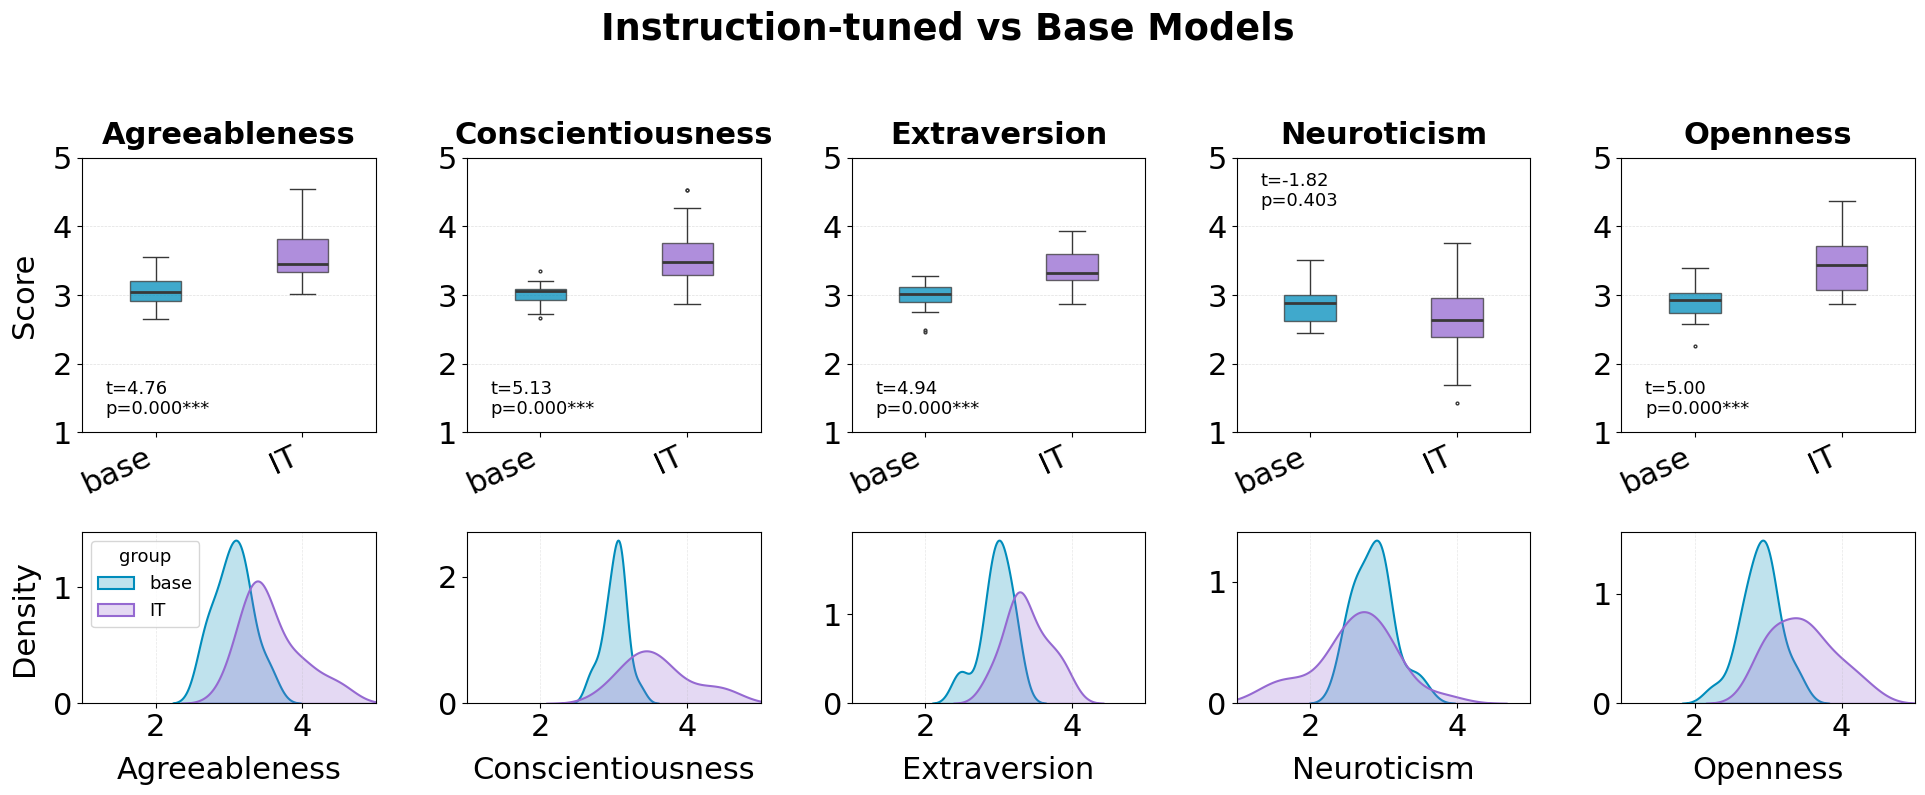

In [6]:
### 5) FIGURE — instruction-tuned vs base
# Reuse bonferroni_ttest for annotation (independent groups here)
stats_annot = bonferroni_ttest(df_it_base, "group", cols=OCEAN_COLS)

fig = plot_binary_comparison(
    df_it_base,
    group_col="group",
    title="Instruction-tuned vs Base Models",
    palette=BINARY_PAL_BLUE_PURPLE,
    order=["base", "IT"],
    stats_df=stats_annot,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_it_vs_base.pdf",
    t_test = True
)
plt.show()

## 3.2 Open-weight vs Proprietary

In [7]:
### 6) OPEN-WEIGHT vs PROPRIETARY
df_lic    = df_metadata.dropna(subset=["license_group"] + OCEAN_COLS)
stats_lic = bonferroni_ttest(df_lic, "license_group", cols=OCEAN_COLS)

print_group_stats(df_lic, "license_group")
print()
print(stats_lic.to_string(index=False))


───────────────────────────────────────────────────────
Mean & SD by license_group
───────────────────────────────────────────────────────

  [open-weight]  n=134
    Agreeableness            : mean=3.822  sd=0.567
    Conscientiousness        : mean=3.805  sd=0.597
    Extraversion             : mean=3.533  sd=0.490
    Neuroticism              : mean=2.271  sd=0.584
    Openness                 : mean=3.516  sd=0.615

  [proprietary]  n=110
    Agreeableness            : mean=4.246  sd=0.402
    Conscientiousness        : mean=4.347  sd=0.438
    Extraversion             : mean=3.800  sd=0.404
    Neuroticism              : mean=1.803  sd=0.422
    Openness                 : mean=3.972  sd=0.505

            trait      group1      group2      t  p_bonferroni sig
    Agreeableness open-weight proprietary -6.819           0.0 ***
Conscientiousness open-weight proprietary -8.166           0.0 ***
     Extraversion open-weight proprietary -4.662           0.0 ***
      Neuroticism open-

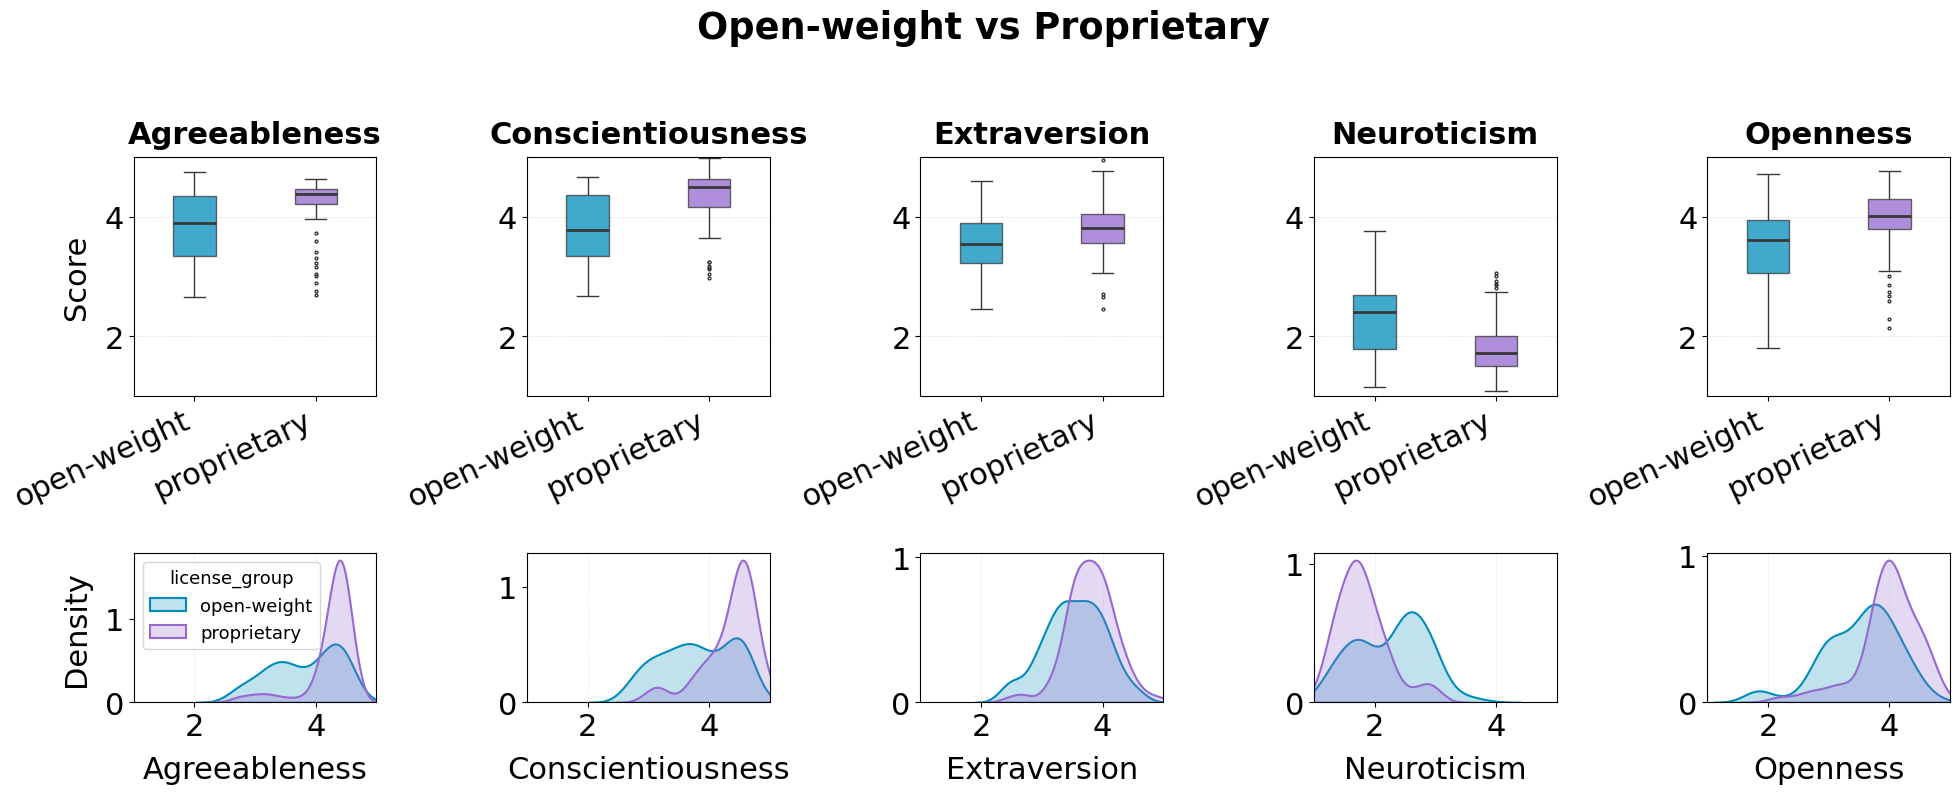

In [8]:
### 7) FIGURE — open-weight vs proprietary
fig = plot_binary_comparison(
    df_lic,
    group_col="license_group",
    title="Open-weight vs Proprietary",
    palette=BINARY_PAL_BLUE_PURPLE,
    order=["open-weight", "proprietary"],
    stats_df=stats_lic,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_proprietary_openweight.pdf",
    t_test = False
)
plt.show()

## 3.3 Reasoning vs Non-Reasoning

In [9]:
### 8) REASONING TRUE vs FALSE
REASONING_COL = "Reasoning"

df_reas = df_metadata.dropna(subset=[REASONING_COL] + OCEAN_COLS).copy()
df_reas[REASONING_COL] = df_reas[REASONING_COL].astype(str).str.strip().str.upper()
df_reas = df_reas[df_reas[REASONING_COL].isin(["TRUE", "FALSE"])]

stats_reas = bonferroni_ttest(df_reas, REASONING_COL, cols=OCEAN_COLS)

print_group_stats(df_reas, REASONING_COL)
print()
print(stats_reas.to_string(index=False))


───────────────────────────────────────────────────────
Mean & SD by Reasoning
───────────────────────────────────────────────────────

  [FALSE]  n=151
    Agreeableness            : mean=3.884  sd=0.508
    Conscientiousness        : mean=3.894  sd=0.557
    Extraversion             : mean=3.624  sd=0.446
    Neuroticism              : mean=2.273  sd=0.546
    Openness                 : mean=3.638  sd=0.475

  [TRUE]  n=92
    Agreeableness            : mean=4.238  sd=0.512
    Conscientiousness        : mean=4.315  sd=0.558
    Extraversion             : mean=3.709  sd=0.507
    Neuroticism              : mean=1.700  sd=0.388
    Openness                 : mean=3.870  sd=0.760

            trait group1 group2      t  p_bonferroni sig
    Agreeableness  FALSE   TRUE -5.250        0.0000 ***
Conscientiousness  FALSE   TRUE -5.714        0.0000 ***
     Extraversion  FALSE   TRUE -1.325        0.9338  ns
      Neuroticism  FALSE   TRUE  9.531        0.0000 ***
         Openness  FALSE

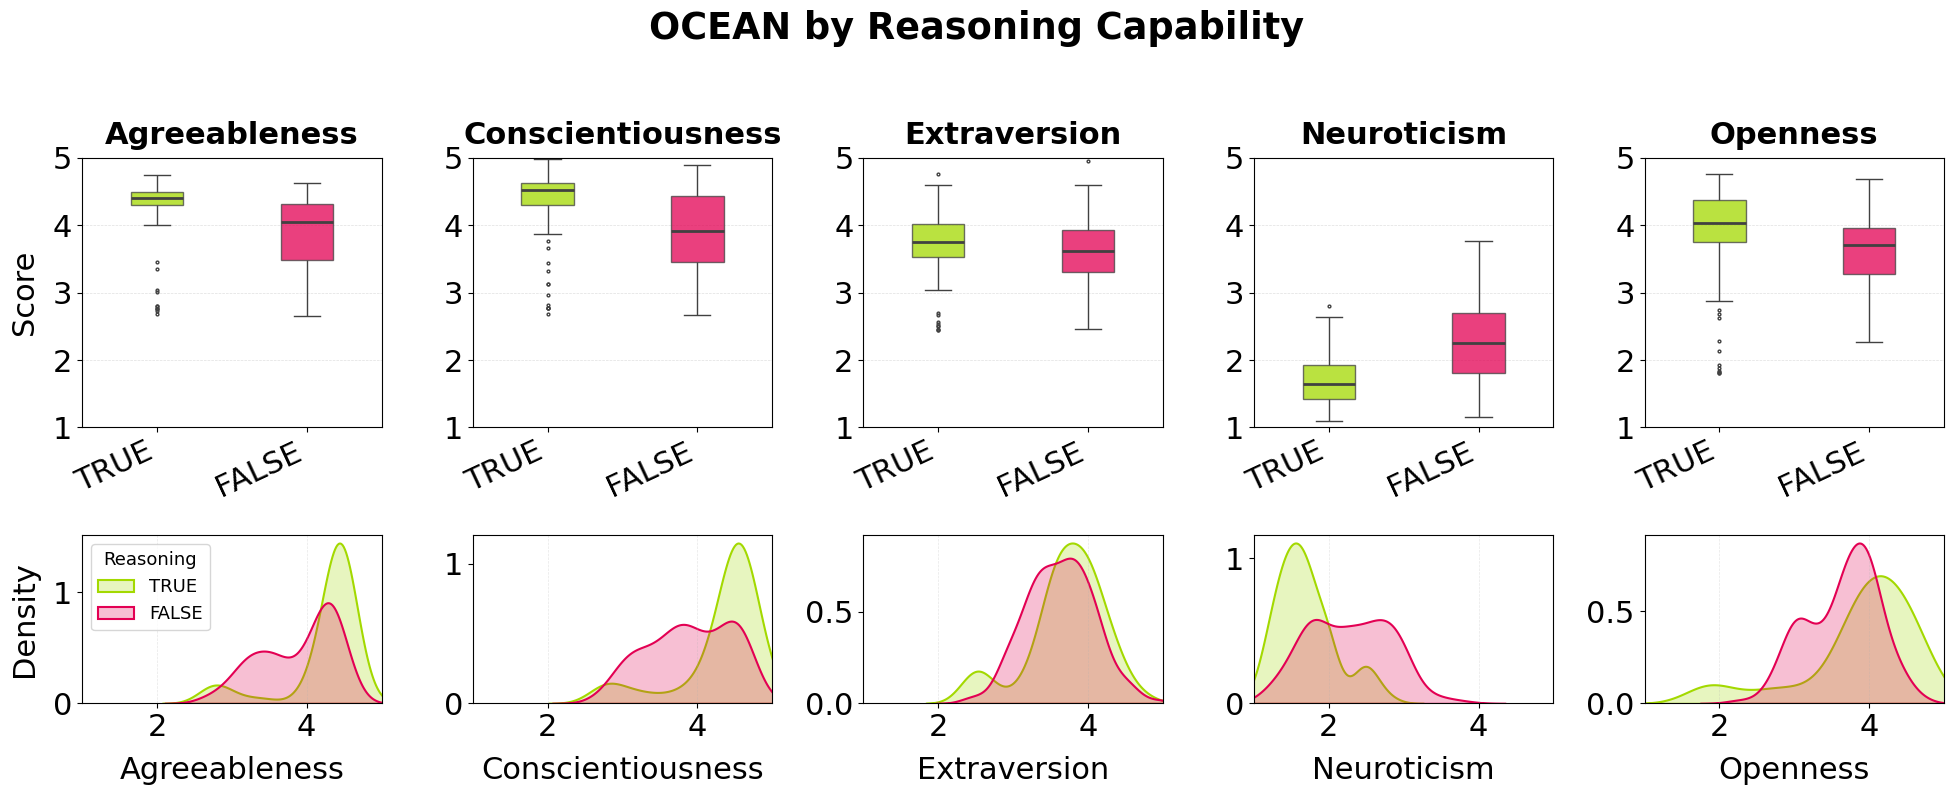

In [10]:
### 9) FIGURE — reasoning vs non-reasoning
fig = plot_binary_comparison(
    df_reas,
    group_col=REASONING_COL,
    title="OCEAN by Reasoning Capability",
    palette=BINARY_PAL_GREEN_RED,
    order=["TRUE", "FALSE"],
    stats_df=stats_reas,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_reasoning.pdf",
    t_test=False
)
plt.show()

## 3.4 Geographic Origin

In [11]:
### 10) COUNTRY OF ORIGIN
df_metadata["Country"] = df_metadata["Country"].replace({
    "china": "China", "france": "France", "US": "US",
})

country_counts = df_metadata["Country"].value_counts()
valid_countries = country_counts[country_counts > 5].index

df_ctry = (
    df_metadata[df_metadata["Country"].isin(valid_countries)]
    .dropna(subset=["Country"] + OCEAN_COLS)
)
ctry_order = (
    df_ctry.groupby("Country")["Openness"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

print_group_stats(df_ctry, "Country")


───────────────────────────────────────────────────────
Mean & SD by Country
───────────────────────────────────────────────────────

  [China]  n=98
    Agreeableness            : mean=4.103  sd=0.559
    Conscientiousness        : mean=4.104  sd=0.613
    Extraversion             : mean=3.663  sd=0.507
    Neuroticism              : mean=1.888  sd=0.542
    Openness                 : mean=3.695  sd=0.699

  [France]  n=20
    Agreeableness            : mean=3.888  sd=0.330
    Conscientiousness        : mean=3.821  sd=0.399
    Extraversion             : mean=3.694  sd=0.366
    Neuroticism              : mean=2.510  sd=0.400
    Openness                 : mean=3.753  sd=0.428

  [US]  n=112
    Agreeableness            : mean=3.999  sd=0.537
    Conscientiousness        : mean=4.091  sd=0.600
    Extraversion             : mean=3.661  sd=0.463
    Neuroticism              : mean=2.081  sd=0.557
    Openness                 : mean=3.777  sd=0.562


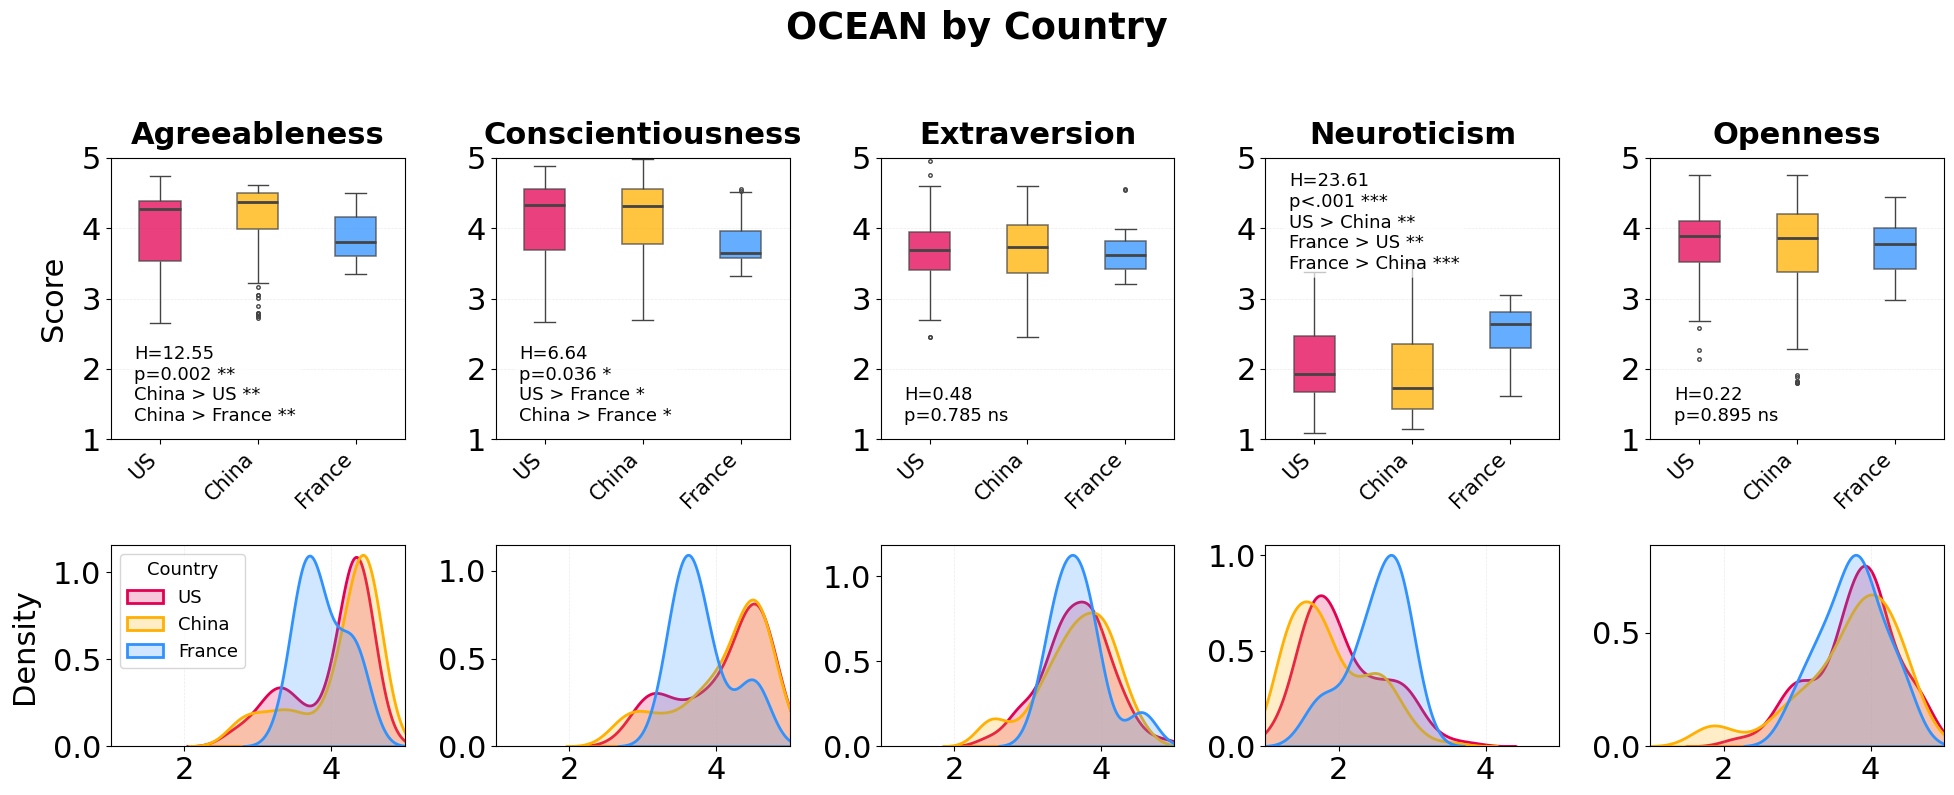

In [12]:
### 11) FIGURE — geographic origin
fig = plot_multigroup_comparison(
    df_ctry,
    group_col="Country",
    title="OCEAN by Country",
    palette=sns.color_palette(TRI_COLOR, df_ctry["Country"].nunique()),
    order=ctry_order,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_countries.pdf",
)
plt.show()

## 3.5 Model Family Profiles

In [13]:
### 12) MODEL FAMILY — group small families into 'other'
MIN_MODELS = 3

df_fam_base  = df_metadata.dropna(subset=["Family"] + OCEAN_COLS)
family_counts = df_fam_base["Family"].value_counts()
keep_families = family_counts[family_counts >= MIN_MODELS].index.tolist()

df_family = df_fam_base.copy()
df_family["FamilyGrouped"] = np.where(
    df_family["Family"].isin(keep_families),
    df_family["Family"],
    "other",
)

family_order = (
    df_family[df_family["FamilyGrouped"] != "other"]
    .groupby("FamilyGrouped")["Openness"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
) + ["other"]

print(df_family["FamilyGrouped"].value_counts())
print_group_stats(df_family, "FamilyGrouped")

FamilyGrouped
qwen        47
other       34
gpt         21
mistral     20
gemma       16
llama       14
glm         12
deepseek    10
grok        10
claude       9
seed         7
gemini       7
minimax      6
kimi         5
mimo         4
nemotron     4
o-series     4
falcon       4
gpt-oss      3
granite      3
trinity      3
Name: count, dtype: int64

───────────────────────────────────────────────────────
Mean & SD by FamilyGrouped
───────────────────────────────────────────────────────

  [claude]  n=9
    Agreeableness            : mean=4.268  sd=0.238
    Conscientiousness        : mean=4.305  sd=0.277
    Extraversion             : mean=3.533  sd=0.180
    Neuroticism              : mean=1.919  sd=0.180
    Openness                 : mean=4.016  sd=0.084

  [deepseek]  n=10
    Agreeableness            : mean=3.821  sd=0.735
    Conscientiousness        : mean=3.703  sd=0.714
    Extraversion             : mean=3.601  sd=0.773
    Neuroticism              : mean=2.179  sd=0.292


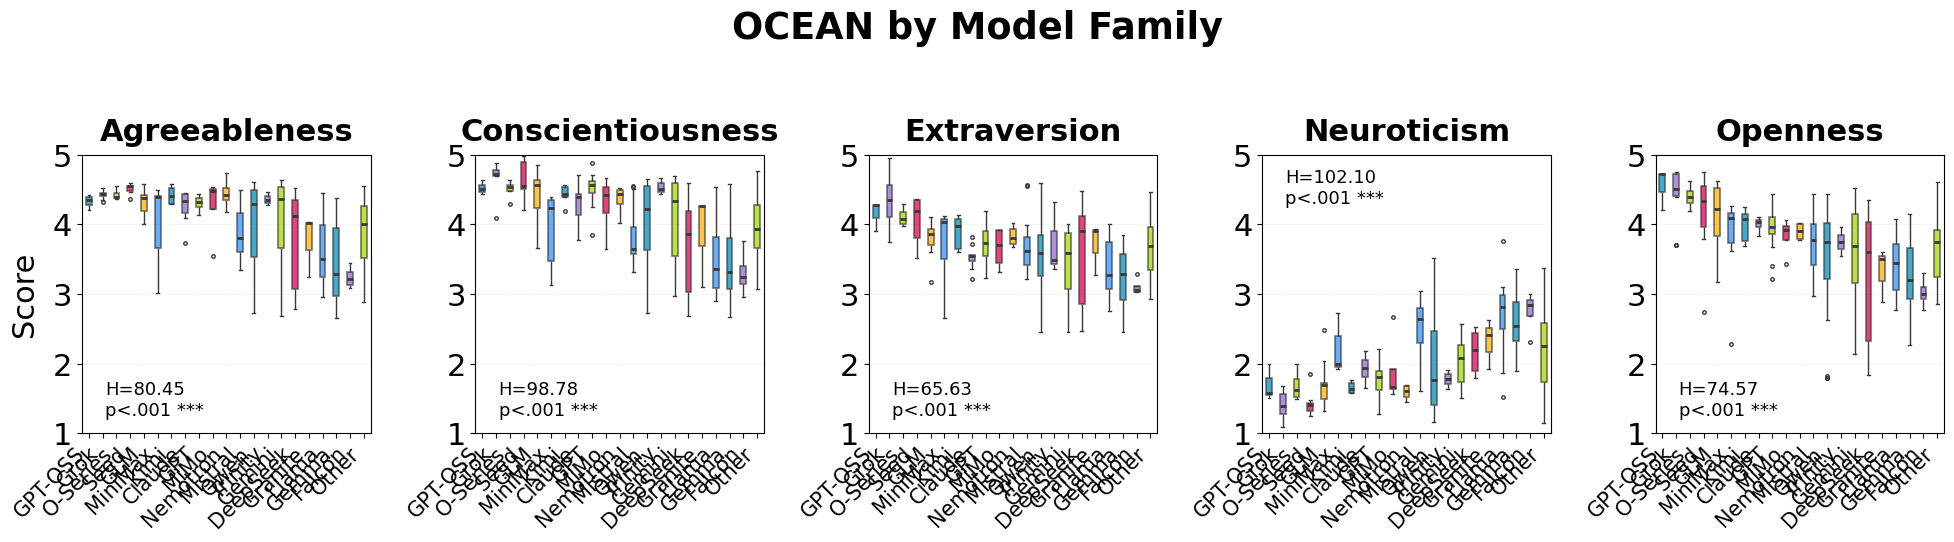

In [14]:
### 13) FIGURE — model family boxplot
df_family["FamilyGroupedClean"] = (
    df_family["FamilyGrouped"]
    .map(FAMILY_LABELS)
    .fillna(df_family["FamilyGrouped"])  # fallback if missing
)

n_families = df_family["FamilyGroupedClean"].nunique()

family_order_clean = [
    FAMILY_LABELS.get(x, x)
    for x in family_order
]

fig = plot_multigroup_comparison(
    df_family,
    group_col="FamilyGroupedClean",
    title="OCEAN by Model Family",
    palette=sns.color_palette(IMPACT_SIX, n_families),
    order=family_order_clean,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_families.pdf",
    figsize=(4 * len(OCEAN_COLS), 5.5),
    test = True,
    posthoc = False,
    kde = False
)
plt.show()

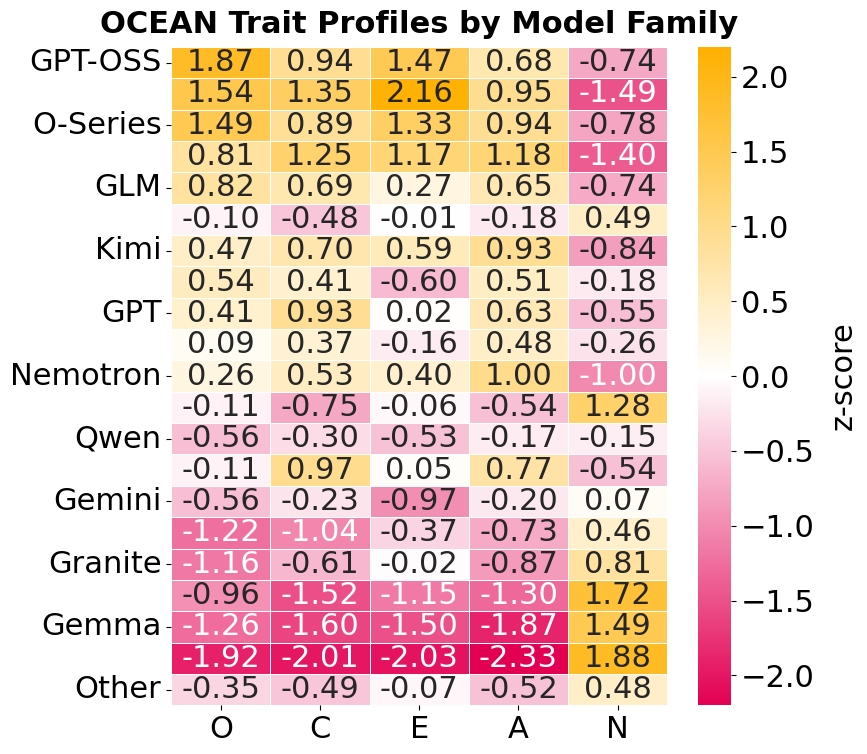

In [15]:
### 14) FIGURE — model family z-score heatmap
fig = plot_family_heatmap(
    df_family,
    group_col="FamilyGrouped",
    order=family_order,
    cols=OCEAN_COLS,
    title="OCEAN Trait Profiles by Model Family",
    save_path="../../doc/figs/fig_heatmap_families.pdf",
)
plt.show()

In [16]:
# 15) GIF ANIMATION MODEL FAMILIES

TRAIT_ORDER = [
    "Openness",
    "Conscientiousness",
    "Extraversion",
    "Agreeableness",
    "Neuroticism",
]

PRIORITY = ["gpt", "claude", "gemini", "qwen", "minimax", "mimo", "trinity",
            "o-series", "gpt-oss", "grok", "seed", "glm", "kimi", "nemotron",
            "mistral", "granite", "deepseek",
            "llama", "gemma", "falcon", "other"]

all_families = df_family["FamilyGrouped"].unique().tolist()

family_order     = [f for f in PRIORITY if f in all_families]

make_all_plots(
    df_family=df_family,
    family_order=family_order,
    trait_order=TRAIT_ORDER,
    family_labels=FAMILY_LABELS,
    out_dir="../../doc/figs/gif/all",
    gif_path="../../doc/figs/gif/all.gif",
    overview_path="../../doc/figs/gif/ocean_overview_real.png",
    gif_duration_ms=1400,
)

  ✓  ../../doc/figs/gif/all/00_gpt.png
  ✓  ../../doc/figs/gif/all/01_claude.png
  ✓  ../../doc/figs/gif/all/02_gemini.png
  ✓  ../../doc/figs/gif/all/03_qwen.png
  ✓  ../../doc/figs/gif/all/04_minimax.png
  ✓  ../../doc/figs/gif/all/05_mimo.png
  ✓  ../../doc/figs/gif/all/06_trinity.png
  ✓  ../../doc/figs/gif/all/07_o-series.png
  ✓  ../../doc/figs/gif/all/08_gpt-oss.png
  ✓  ../../doc/figs/gif/all/09_grok.png
  ✓  ../../doc/figs/gif/all/10_seed.png
  ✓  ../../doc/figs/gif/all/11_glm.png
  ✓  ../../doc/figs/gif/all/12_kimi.png
  ✓  ../../doc/figs/gif/all/13_nemotron.png
  ✓  ../../doc/figs/gif/all/14_mistral.png
  ✓  ../../doc/figs/gif/all/15_granite.png
  ✓  ../../doc/figs/gif/all/16_deepseek.png
  ✓  ../../doc/figs/gif/all/17_llama.png
  ✓  ../../doc/figs/gif/all/18_gemma.png
  ✓  ../../doc/figs/gif/all/19_falcon.png
  ✓  ../../doc/figs/gif/all/20_other.png
  ✓  GIF      → ../../doc/figs/gif/all.gif

Done — 21 PNGs + overview + GIF


(['../../doc/figs/gif/all/00_gpt.png',
  '../../doc/figs/gif/all/01_claude.png',
  '../../doc/figs/gif/all/02_gemini.png',
  '../../doc/figs/gif/all/03_qwen.png',
  '../../doc/figs/gif/all/04_minimax.png',
  '../../doc/figs/gif/all/05_mimo.png',
  '../../doc/figs/gif/all/06_trinity.png',
  '../../doc/figs/gif/all/07_o-series.png',
  '../../doc/figs/gif/all/08_gpt-oss.png',
  '../../doc/figs/gif/all/09_grok.png',
  '../../doc/figs/gif/all/10_seed.png',
  '../../doc/figs/gif/all/11_glm.png',
  '../../doc/figs/gif/all/12_kimi.png',
  '../../doc/figs/gif/all/13_nemotron.png',
  '../../doc/figs/gif/all/14_mistral.png',
  '../../doc/figs/gif/all/15_granite.png',
  '../../doc/figs/gif/all/16_deepseek.png',
  '../../doc/figs/gif/all/17_llama.png',
  '../../doc/figs/gif/all/18_gemma.png',
  '../../doc/figs/gif/all/19_falcon.png',
  '../../doc/figs/gif/all/20_other.png'],
 '../../doc/figs/gif/ocean_overview_real.png',
 '../../doc/figs/gif/all.gif')

## 3.6 Parameter Scale

In [17]:
### 16) SIZE GROUP COMPARISON (Kruskal-Wallis)
SIZE_ORDER = ["small (<10B)", "medium (10–100B)", "large (>100B)"]

df_sz      = df_metadata.dropna(subset=["Size"] + OCEAN_COLS)
sz_present = [s for s in SIZE_ORDER if s in df_sz["Size"].values]

print_group_stats(df_sz, "Size")


───────────────────────────────────────────────────────
Mean & SD by Size
───────────────────────────────────────────────────────

  [large]  n=38
    Agreeableness            : mean=4.197  sd=0.437
    Conscientiousness        : mean=4.190  sd=0.472
    Extraversion             : mean=3.805  sd=0.469
    Neuroticism              : mean=1.866  sd=0.444
    Openness                 : mean=3.787  sd=0.577

  [medium]  n=47
    Agreeableness            : mean=3.934  sd=0.521
    Conscientiousness        : mean=3.903  sd=0.574
    Extraversion             : mean=3.597  sd=0.480
    Neuroticism              : mean=2.214  sd=0.547
    Openness                 : mean=3.559  sd=0.681

  [small]  n=49
    Agreeableness            : mean=3.422  sd=0.444
    Conscientiousness        : mean=3.413  sd=0.466
    Extraversion             : mean=3.260  sd=0.369
    Neuroticism              : mean=2.639  sd=0.485
    Openness                 : mean=3.265  sd=0.473

  [undisclosed]  n=109
    Agreeable

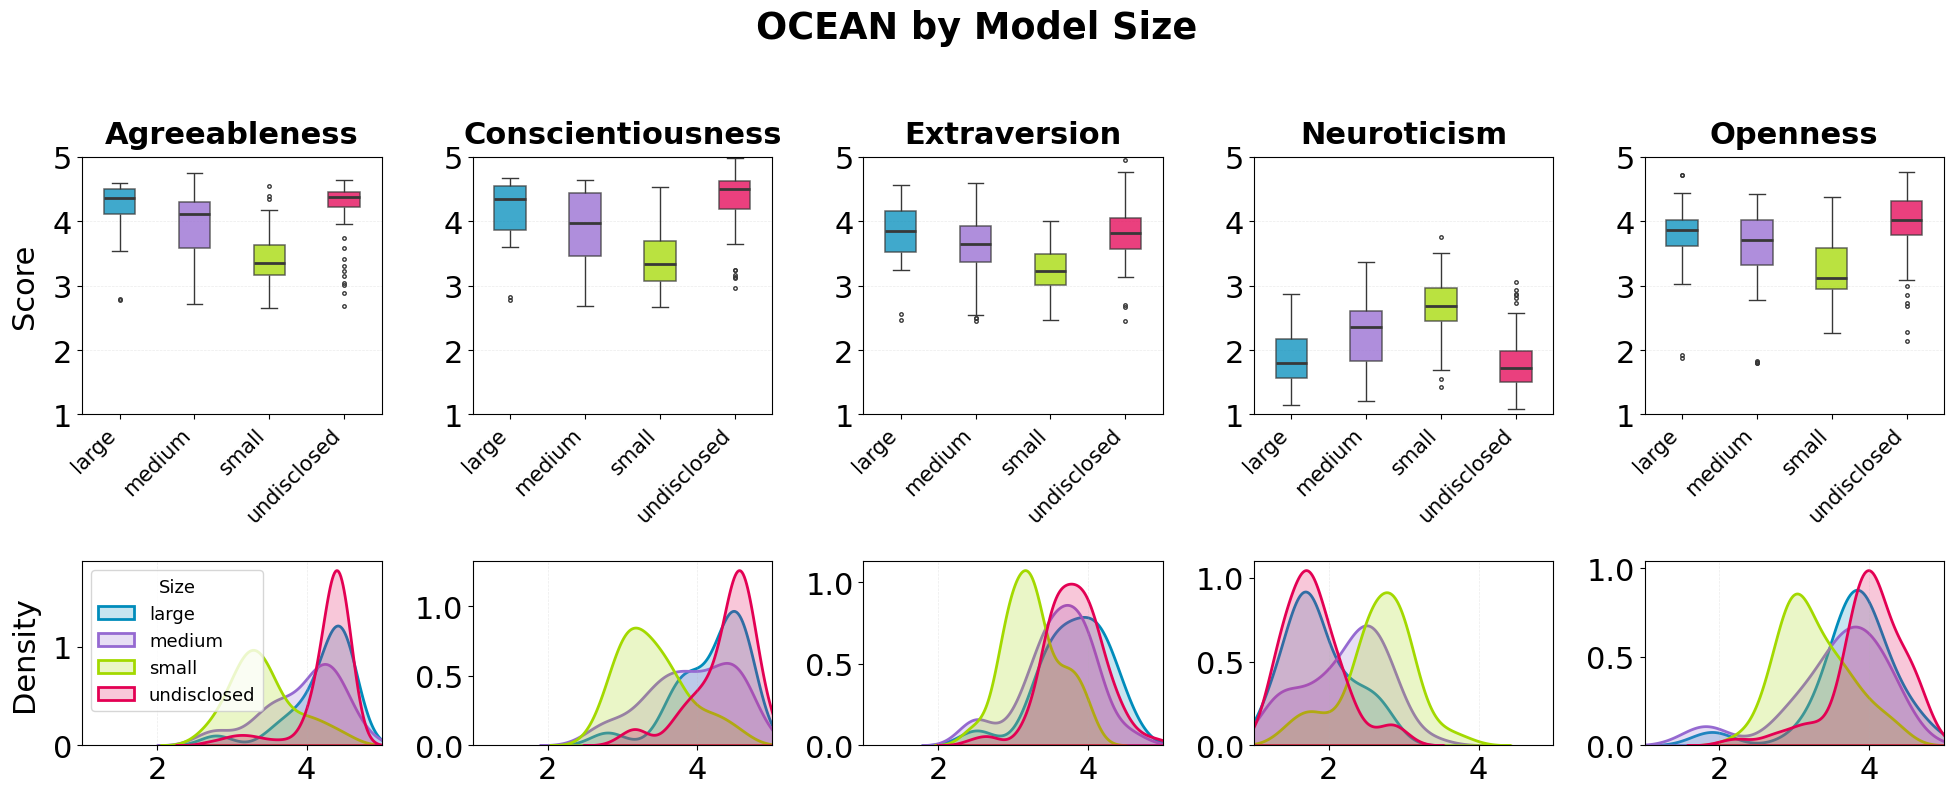

In [18]:
### 17) FIGURE — model size groups
fig = plot_multigroup_comparison(
    df_sz,
    group_col="Size",
    title="OCEAN by Model Size",
    palette=IMPACT_SIX,
    order=sz_present,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_sizes.pdf",
    test=False,
    posthoc = False,
    figsize=(4 * len(OCEAN_COLS), 8),
)
plt.show()

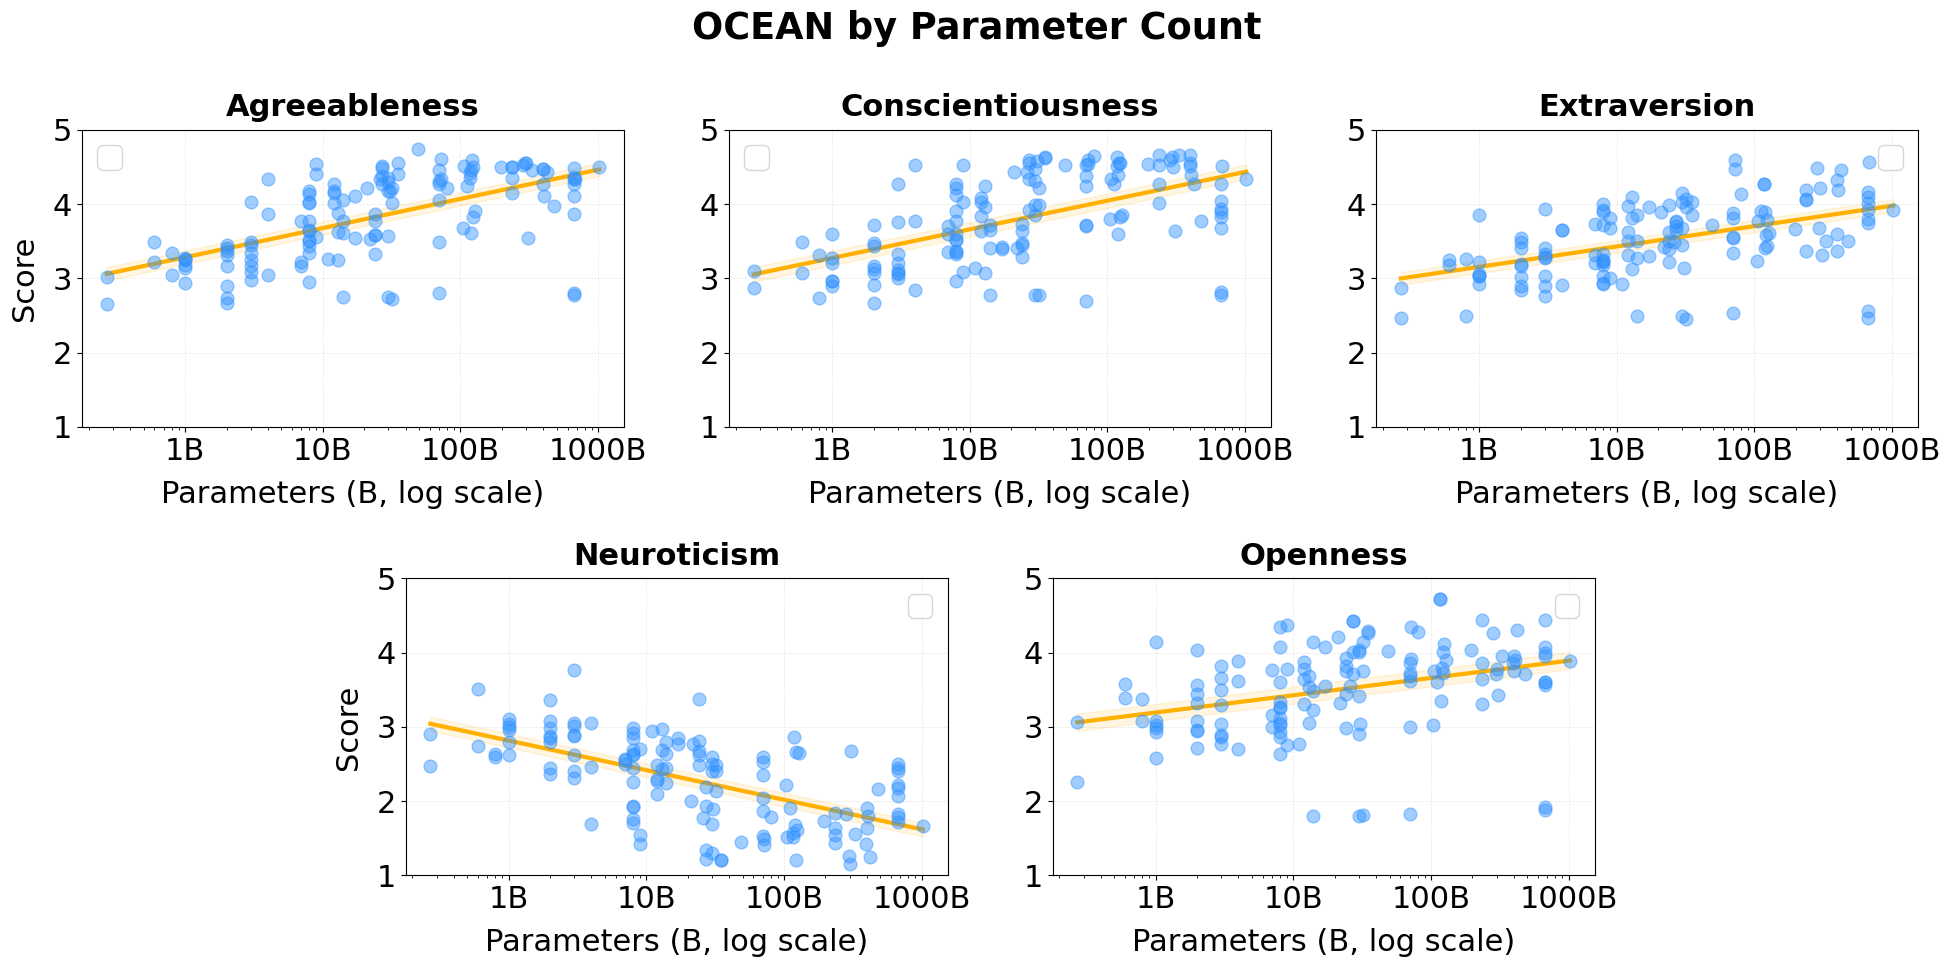

In [19]:
### 18) CONTINUOUS PARAMETER SCALE (OLS regression on log10 params)
fig = plot_param_scale_regression(
    df_metadata,
    params_col="Parameters_B",
    palette=BINARY_PAL_BLUE_ORANGE,
    cols=OCEAN_COLS,
    title="OCEAN by Parameter Count",
    save_path="../../doc/figs/fig_size_regression.pdf",
    test = False,
    figsize=(4 * len(OCEAN_COLS), 10),
)
plt.show()

## 3.7 Release Date Trends

In [20]:
### 19) RELEASE DATE — preprocessing
import pandas as pd

ref = pd.Timestamp("2026-05-12")

df_metadata["release_dt"]     = pd.to_datetime(df_metadata["Release_date"], errors="coerce")
df_metadata["release_months"] = (df_metadata["release_dt"] - ref).dt.days / 30.44

In [21]:
### 20) REGRESSION SUMMARY — release date vs OCEAN
df_rel     = df_metadata.dropna(subset=["release_months"] + OCEAN_COLS)
summary_df = regression_summary(df_rel, x_col="release_months", y_cols=OCEAN_COLS)

print("=== OLS: OCEAN ~ release_months ===")
print(summary_df.to_string(index=False))

=== OLS: OCEAN ~ release_months ===
            trait    slope      r  p_value sig
    Agreeableness  0.02654  0.350  0.00000 ***
Conscientiousness  0.03064  0.366  0.00000 ***
      Neuroticism -0.03306 -0.414  0.00000 ***
         Openness  0.02378  0.277  0.00001 ***
     Extraversion  0.00943  0.142  0.02729   *


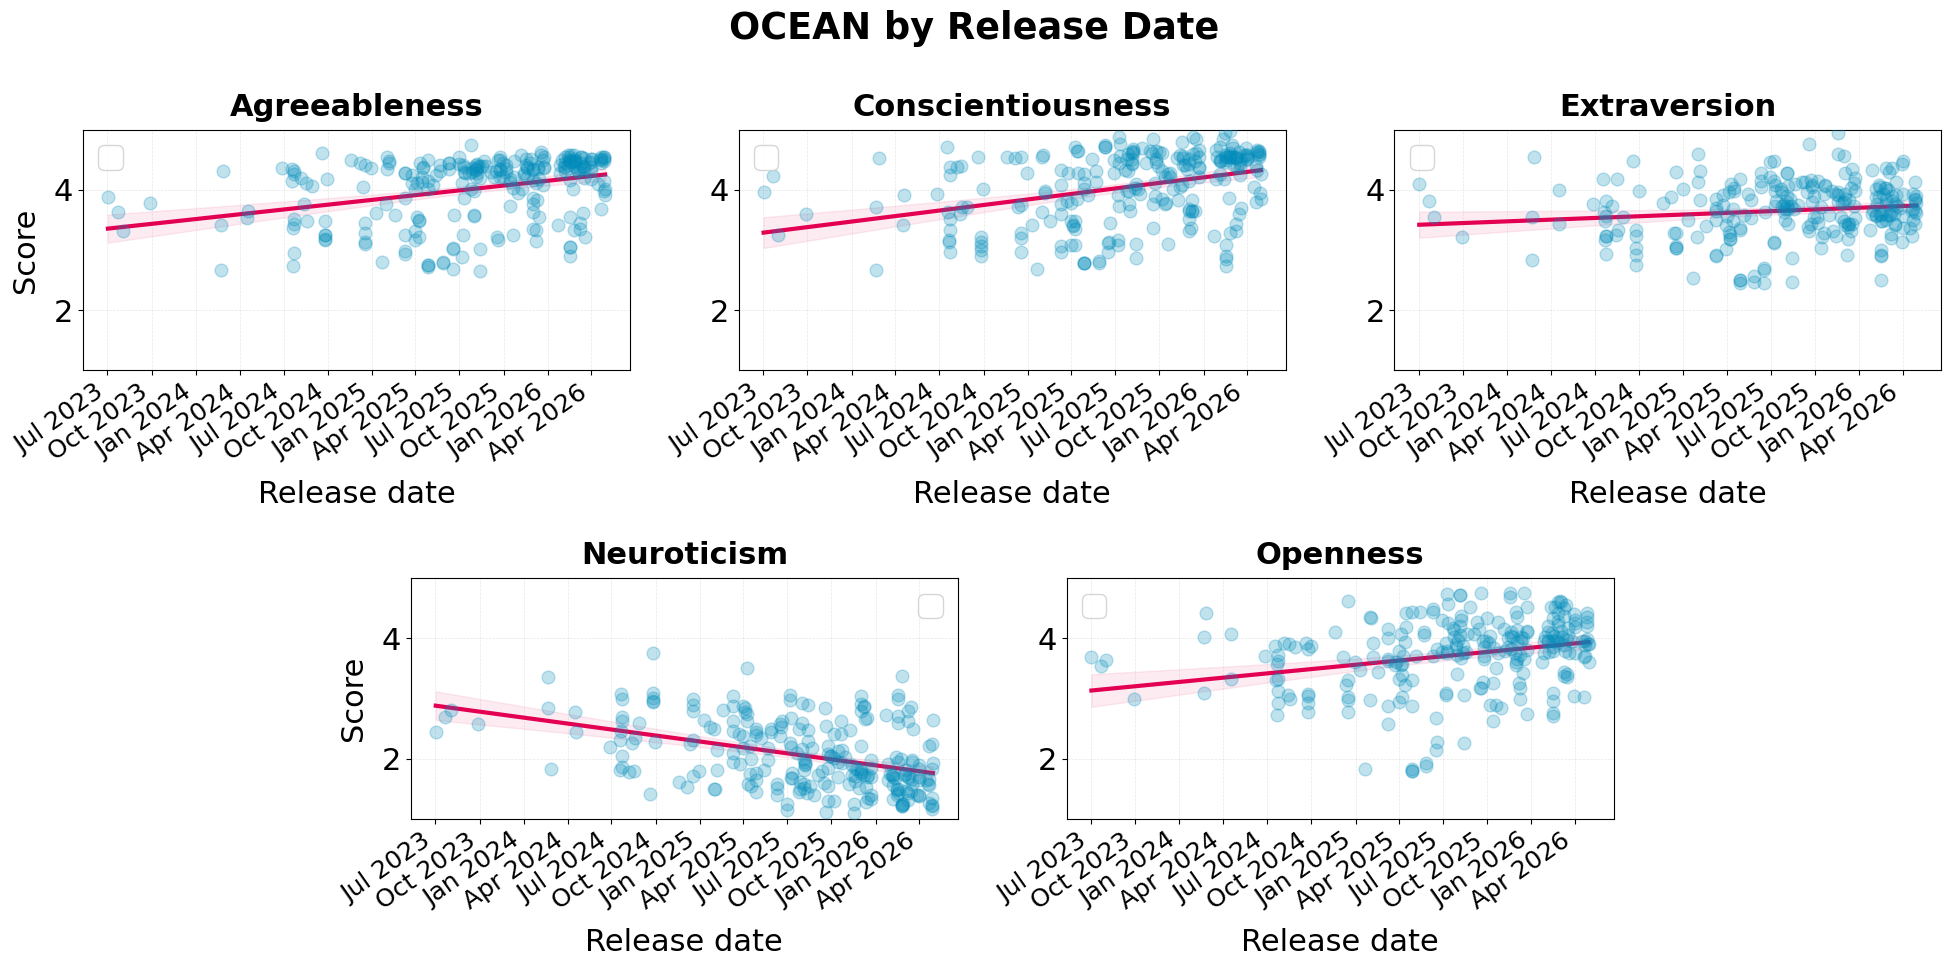

In [22]:
### 21) FIGURE — release date regression
df_rel = df_metadata.dropna(subset=["release_dt", "release_months"] + OCEAN_COLS)

fig = plot_release_date_regression(
    df_rel,
    date_col="release_dt",
    release_months_col="release_months",
    palette=BINARY_PAL_BLUE_PINK,
    cols=OCEAN_COLS,
    title="OCEAN by Release Date",
    save_path="../../doc/figs/fig_release_date.png",
    test=False,
    figsize=(4 * len(OCEAN_COLS), 10),
)
plt.show()